In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
from ALLCools.mcds import MCDS
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import ttest_ind
from pathlib import Path

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['path.simplify'] = False  # keep exact vectors

In [46]:
# ================================
# Nature Communications font settings
# ================================
import matplotlib as mpl
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']


# Set global defaults (put this once at the top of your script)
mpl.rcParams.update({
          # Nature requires Arial or Helvetica
    'font.size': 12,# base font size
    'font.weight': 'bold',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})



In [47]:
#parameters 
metadata_path = '../pooledoocytes/postreviewanalysis/pca/CellMetadata_PassQC_alloocytes_withyear_mtreads_sub.csv'

# change this to the paths to your MCDS files
mcds_path = 'mcds/chrom10k/'
# Dimension name used to do clustering
obs_dim = 'cell'
var_dim = 'chrom10k'

min_cov = 300
max_cov = 1000

#chrom_to_remove
exclude_chromosome= ['chrY', 'chrUn', 'Chromosome', 'NW']

OUT_DIR = Path("globalplots_per_feature_chrom10k")
OUT_DIR.mkdir(exist_ok=True)



In [48]:
# load metadata

metadata = pd.read_csv(metadata_path, index_col=0, sep="\t")
#table = pd.read_csv("allc_table.csv", index_col=0, header=None)
#metadata = metadata[metadata["Type"] == "PO"]
total_cells = metadata.shape[0]
print(f'Metadata of {total_cells} cells')
metadata

Metadata of 104 cells


,SampleI,AnimalID,Date,Animdate,Collection,Year,Type.of.sample,WellID,WellBarcode,Type,TotalRead,mCGFrac,Group,SampleName,Path,Bamfile,Total.Reads,Mitochondrial.Reads,MT.Fraction,MT.Percentage
SampleID,,,,,,,,,,,,,,,,,,,,
4129944636SOeNC1L1S,4129944636SOeNC1L1,41299,44636,d1,1,2022,Single Oocyte,L1,AACCGTGT,SO,2000000,0.705,Stressed,4129944636SOeNC1L1S_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,41299_44636_SOe_NC1_L1_1_val_1_bismark_bt2_pe....,2105900,22264,NaN,NaN
4211144957SO1NC1H4C,4211144957SO1NC1H4,42111,44957,g1,1,2023,Single Oocyte #1,H4,CGATGTTC,SO,2000000,0.675,Control,4211144957SO1NC1H4C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,42111_44957_SO1_NC1_H4_1_val_1_bismark_bt2_pe....,2009852,41954,NaN,NaN
4499445005SO1NC1P5C,4499445005SO1NC1P5,44994,45005,m2,2,2023,Single Oocyte #1,P5,CATGGATC,SO,2100000,0.602,Control,4499445005SO1NC1P5C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,44994_45005_SO1_NC1_P5_1_val_1_bismark_bt2_pe....,2128036,16538,NaN,NaN
4146045001PO3NC4G4C,4146045001PO3NC4G4,41460,45001,f2,2,2023,Pooled Oocytes (4) #3,G4,TCGTGCAT,PO,2200000,0.689,Control,4146045001PO3NC4G4C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,41460_45001_PO3_NC4_G4_1_val_1_bismark_bt2_pe....,2535512,8738,NaN,NaN
4499445005SO3NC1D6C,4499445005SO3NC1D6,44994,45005,m2,2,2023,Single Oocyte #3,D6,TGCGTAAC,SO,2200000,0.653,Control,4499445005SO3NC1D6C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,44994_45005_SO3_NC1_D6_1_val_1_bismark_bt2_pe....,2550590,16800,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265145042SO3NC1F5S,4265145042SO3NC1F5,42651,45042,i1,1,2023,Single Oocyte #3,F5,CACACATC,SO,28700000,0.698,Stressed,4265145042SO3NC1F5S_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,42651_45042_SO3_NC1_F5_1_val_1_bismark_bt2_pe....,33733488,50188,NaN,NaN
4302844664PO2NC5K5C,4302844664PO2NC5K5,43028,44664,j1,1,2022,Pooled Oocytes (5) #2,K5,AGCGAGAT,PO,33700000,0.715,Control,4302844664PO2NC5K5C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,43028_44664_PO2_NC5_K5_1_val_1_bismark_bt2_pe....,37117632,64892,NaN,NaN
4139144923PO1NC3H3C,4139144923PO1NC3H3,41391,44923,e1,1,2022,Pooled Oocytes (3) #1,H3,AGTCGAAG,PO,42800000,0.700,Control,4139144923PO1NC3H3C_1_val_1_bismark_bt2_pe.all...,/share/lasallelab/Ensi/project/allcools/allc_P...,41391_44923_PO1_NC3_H3_1_val_1_bismark_bt2_pe....,48057090,18402,NaN,NaN


In [49]:
mcds = MCDS.open(mcds_path, 
                 var_dim=var_dim, 
                 use_obs=metadata.index)
mcds

<xarray.MCDS>
Dimensions:         (cell: 104, chrom10k: 298615, count_type: 2, mc_type: 2)
Coordinates:
  * cell            (cell) <U20 '3889744643SO1NC1A1S' ... '4660644993PO4NC5F10C'
  * chrom10k        (chrom10k) <U30 'chr1_0' 'chr1_1' ... 'chrY_1175'
    chrom10k_chrom  (chrom10k) <U27 'chr1' 'chr1' 'chr1' ... 'chrY' 'chrY'
    chrom10k_end    (chrom10k) int64 10000 20000 30000 ... 11750000 11753682
    chrom10k_start  (chrom10k) int64 0 10000 20000 ... 11740000 11750000
  * count_type      (count_type) <U3 'mc' 'cov'
  * mc_type         (mc_type) <U3 'CHN' 'CGN'
Data variables:
    chrom10k_da     (cell, chrom10k, mc_type, count_type) uint32 dask.array<chunksize=(10, 37327, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom10k

In [50]:
# you can add the cell metadata into MCDS
mcds.add_cell_metadata(metadata)

In [51]:
total_feature = mcds.get_index(var_dim).size
total_feature

298615

Feature chrom10k mean cov across cells added in MCDS.coords['chrom10k_cov_mean'].


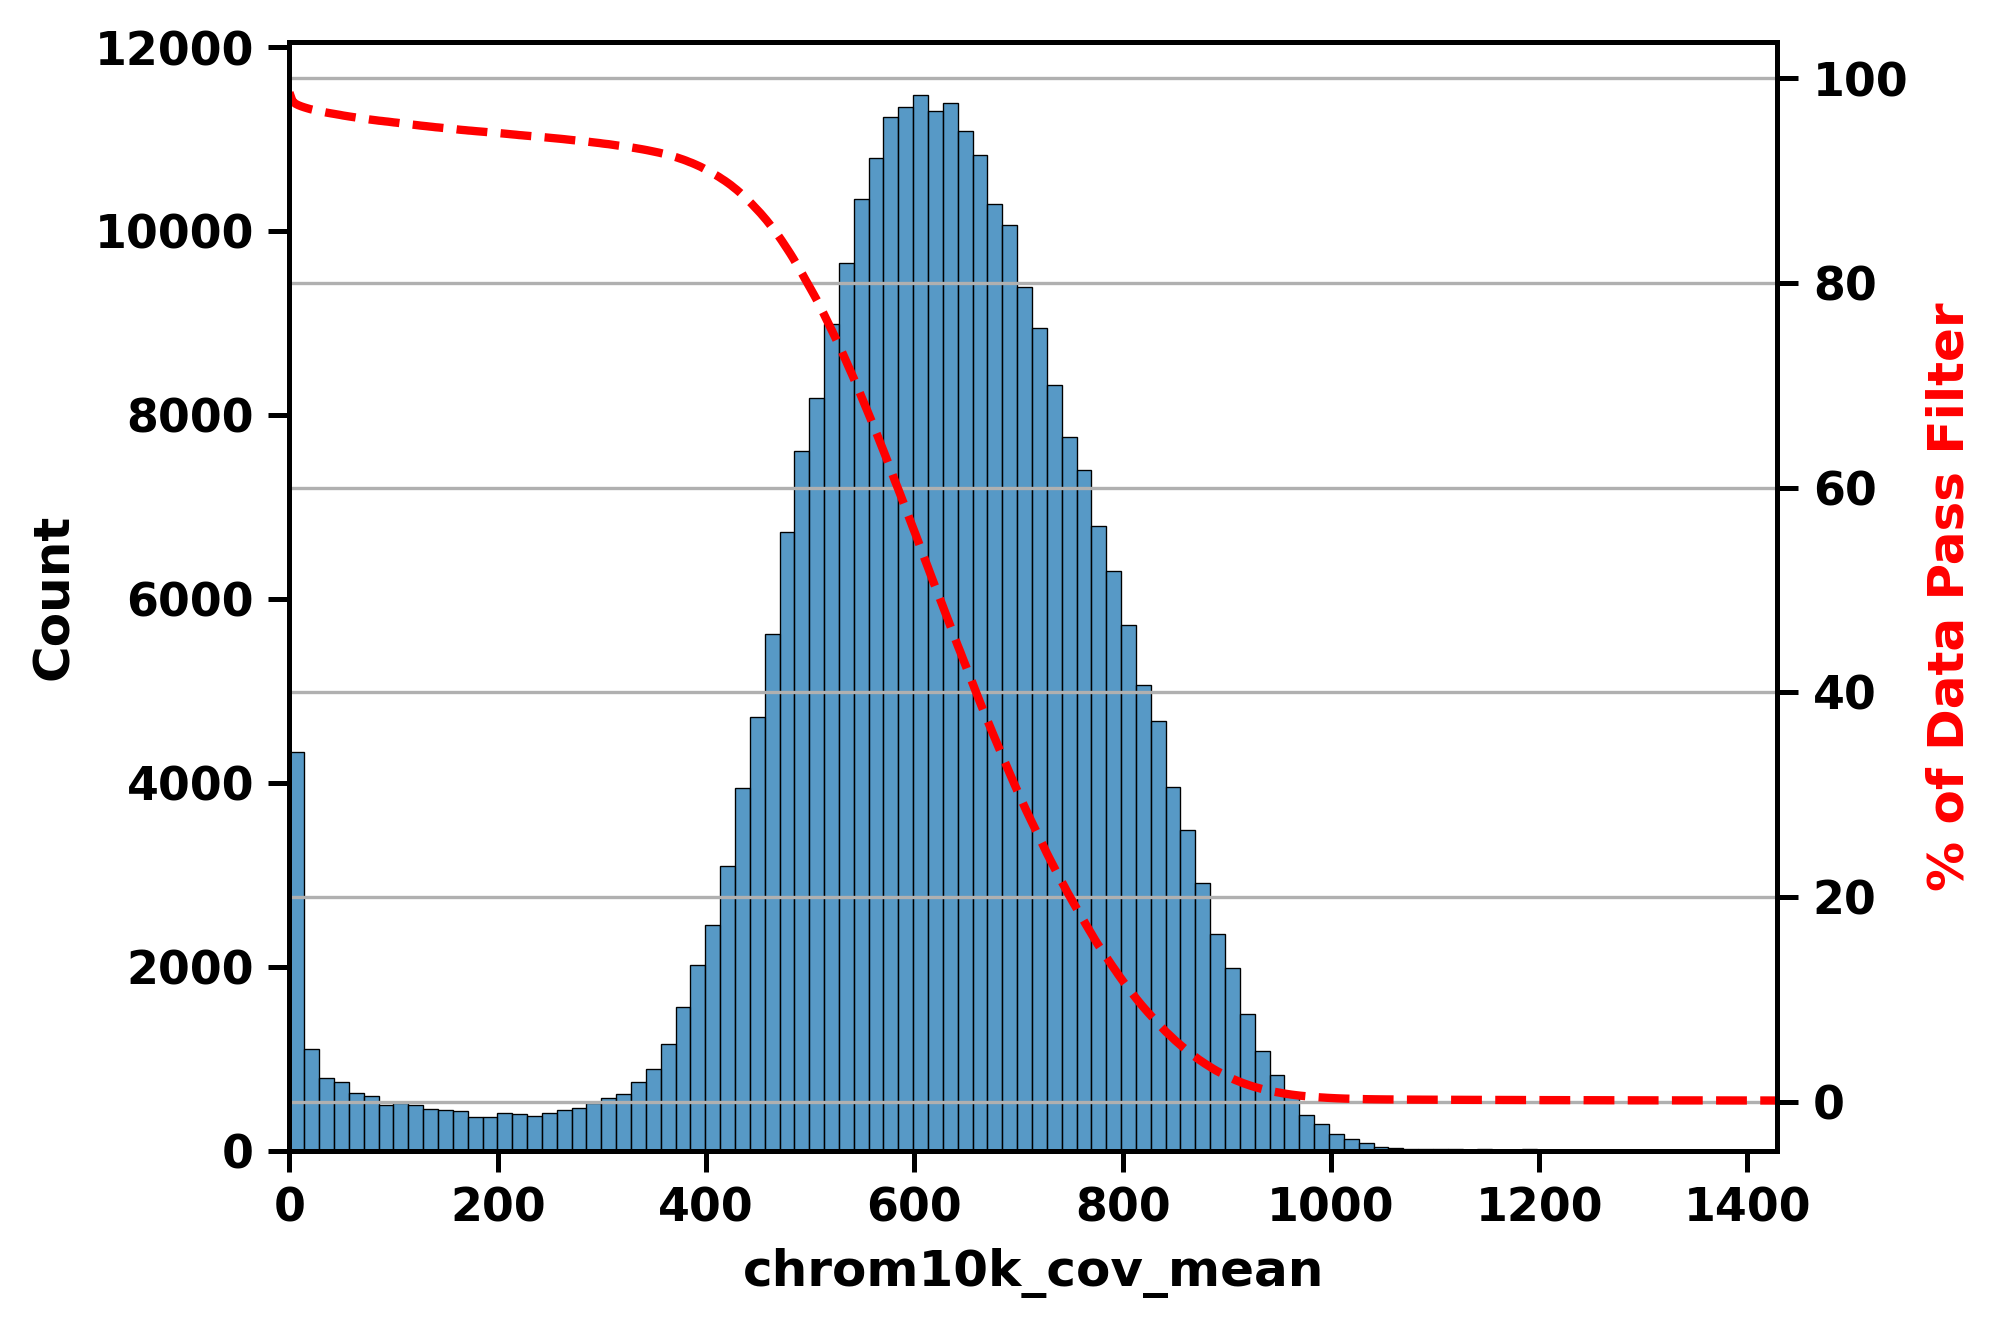

In [52]:
# Assuming mcds is your object and add_feature_cov_mean() generates a plot
mcds.add_feature_cov_mean(var_dim=var_dim)

# Save the plot to a file
#plt.savefig('05b_mcds100kb_featurecoverage.png', dpi=300, bbox_inches='tight')
plt.savefig(f'globalplots_per_feature_{var_dim}/mcds-cov-filtter_{var_dim}.pdf', dpi=300, bbox_inches='tight')

In [53]:
chrom10k_dim_labels = mcds['chrom10k_cov_mean'].values
print(chrom10k_dim_labels)


[ 49.36538462 344.16346154 638.19230769 ...   0.           0.
   0.        ]


In [54]:
# Align chrom100k_cov_mean with chrom100k by creating it as a data variable
mcds = mcds.assign(chrom10k_cov_mean=("chrom10k", mcds["chrom10k_cov_mean"].values))
# Apply the filter on chrom100k based on chrom100k_cov_mean


In [55]:

mcds = mcds.filter_feature_by_cov_mean(
     var_dim="chrom10k",
    min_cov=min_cov,  # minimum coverage
    max_cov=max_cov  # Maximum coverage
)

Before cov mean filter: 298615 chrom10k
 After cov mean filter: 278601 chrom10k 93.3%


In [56]:
mcds = mcds.remove_chromosome(exclude_chromosome)

0 chrom10k features in ['chrY', 'chrUn', 'Chromosome', 'NW'] removed.


In [57]:
#with open('FeatureList.BasicFilter.txt', 'w') as f:
#    for var in mcds.get_index(var_dim).astype(str):
#        f.write(var + '\n')

In [58]:
#add mC Rate 
mcds.add_mc_rate(var_dim=var_dim,
                       normalize_per_cell=False,
                       clip_norm_value=10)

mcds

<xarray.MCDS>
Dimensions:                   (cell: 104, chrom10k: 278601, count_type: 2,
                               mc_type: 2)
Coordinates: (12/28)
  * cell                      (cell) object '3889744643SO1NC1A1S' ... '466064...
  * chrom10k                  (chrom10k) object 'chr1_1' ... 'chrX_NW_0211603...
    chrom10k_chrom            (chrom10k) <U27 'chr1' ... 'chrX_NW_021160383v1...
    chrom10k_end              (chrom10k) int64 20000 30000 40000 ... 20000 30000
    chrom10k_start            (chrom10k) int64 10000 20000 30000 ... 10000 20000
  * count_type                (count_type) <U3 'mc' 'cov'
    ...                        ...
    cell_Bamfile              (cell) object '38897_44643_SO1_NC1_A1_1_val_1_b...
    cell_Total.Reads          (cell) int64 4272186 2856498 ... 9834078 12310004
    cell_Mitochondrial.Reads  (cell) int64 20618 12888 30202 ... 52552 118550
    cell_MT.Fraction          (cell) float64 nan nan nan nan ... nan nan nan nan
    cell_MT.Percentage        (cell) float64 nan nan nan nan ... nan nan nan nan
    chrom10k_cov_mean         (chrom10k) float64 344.2 638.2 ... 598.8 636.0
Data variables:
    chrom10k_da               (cell, chrom10k, mc_type, count_type) uint32 dask.array<chunksize=(10, 36084, 1, 1), meta=np.ndarray>
    chrom10k_da_frac          (cell, chrom10k, mc_type) float64 dask.array<chunksize=(10, 36084, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom10k

In [59]:
#Global plot

Number of bins: 278601
T-statistic: 2.8632178379014483
P-value: 0.0041937778215878525
Cohen's d: 0.007671460503526755


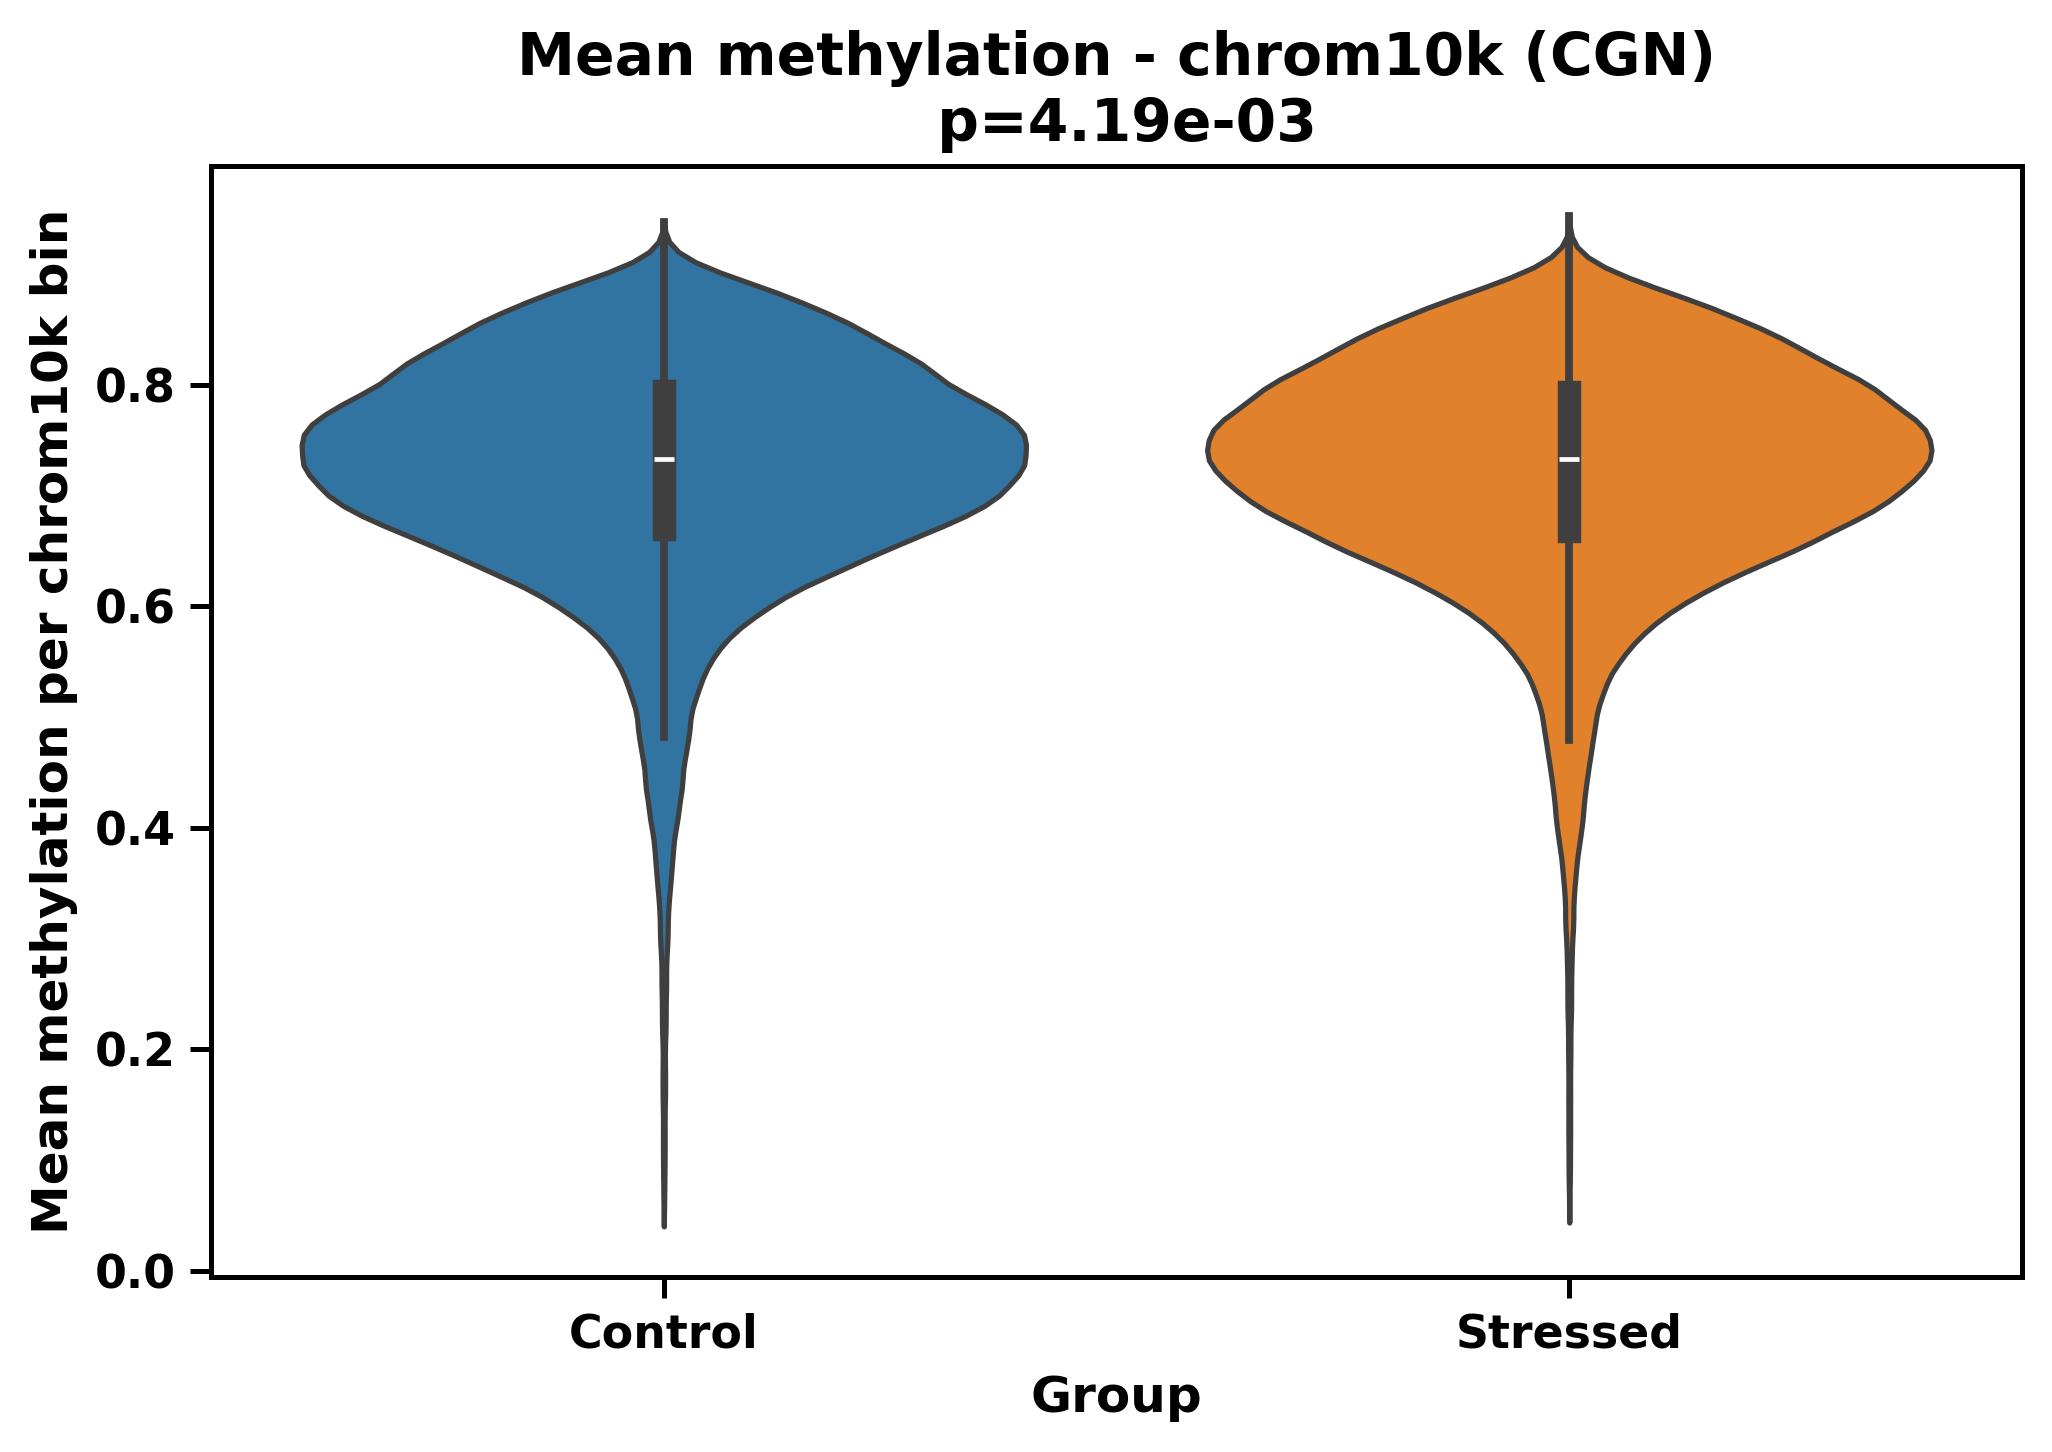

Plot saved to: globalplots_per_feature_chrom10k/violin_CGN_chrom10k_per_feature.pdf


In [60]:
# ============================================
# Title: Per-feature (chrom10k) methylation distribution + t-test
# What this does:
# 1) Compute mean methylation per bin per group
# 2) Build distribution across bins
# 3) Perform Welch’s t-test between groups (bins as units)
# 4) Plot violin distribution
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind


mc_type = "CGN"  # change to "CHN" for mCH
var_dim = "chrom10k"  # just for labeling / filenames

# Extract fraction matrix (cell x chrom10k)
frac = mcds["chrom10k_da_frac"].sel(mc_type=mc_type)

# Convert to pandas (cells x bins)
frac_df = frac.to_pandas()

# Add group info (ensure alignment with frac_df rows)
frac_df["Group"] = mcds.coords["cell_Group"].to_pandas()

# Compute mean methylation per bin per group (Group x bins)
mean_by_bin = frac_df.groupby("Group").mean(numeric_only=True)

# Extract arrays (distribution across bins)
control_bins = mean_by_bin.loc["Control"].to_numpy()
stressed_bins = mean_by_bin.loc["Stressed"].to_numpy()

# Remove NaN/inf bins
mask = np.isfinite(control_bins) & np.isfinite(stressed_bins)
control_bins = control_bins[mask]
stressed_bins = stressed_bins[mask]

# ===================
# T-test (Welch)
# ===================
t_stat, p_val = ttest_ind(control_bins, stressed_bins, equal_var=False, nan_policy="omit")

# Effect size (Cohen's d using pooled SD)
def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx = x.size
    ny = y.size
    pooled_sd = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

d = cohens_d(control_bins, stressed_bins)

print("Number of bins:", len(control_bins))
print("T-statistic:", t_stat)
print("P-value:", p_val)
print("Cohen's d:", d)

# ===================
# Save stats summary
# ===================
stats_df = pd.DataFrame({
    "mc_type": [mc_type],
    "var_dim": [var_dim],
    "n_bins": [len(control_bins)],
    "t_statistic": [t_stat],
    "p_value": [p_val],
    "cohens_d": [d],
    "control_mean": [np.mean(control_bins)],
    "stressed_mean": [np.mean(stressed_bins)]
})

stats_df.to_csv(OUT_DIR / f"global_stats_{mc_type}_{var_dim}.csv", index=False)

# ===================
# Prepare plotting dataframe (long format)
# ===================
df_plot = pd.DataFrame({
    "Group": (["Control"] * len(control_bins)) +
             (["Stressed"] * len(stressed_bins)),
    "mean_methylation": np.concatenate([control_bins, stressed_bins])
})

df_plot.to_csv(OUT_DIR / f"distribution_values_{mc_type}_{var_dim}.csv", index=False)

# ===================
# Make a long-form df for seaborn
df_plot = pd.DataFrame({
    "Group": (["Control"] * len(control_bins)) + (["Stressed"] * len(stressed_bins)),
    "mean_methylation": np.concatenate([control_bins, stressed_bins])
})

# ===================
# Violin Plot
# ===================
plt.figure(figsize=(7, 5))
sns.violinplot(data=df_plot, x="Group", y="mean_methylation", inner="box", cut=0, hue="Group")

plt.title(f"Mean methylation - {var_dim} ({mc_type})\n p={p_val:.2e}")
plt.xlabel("Group")
plt.ylabel(f"Mean methylation per {var_dim} bin")

plt.tight_layout()
outpath = OUT_DIR / f"violin_{mc_type}_{var_dim}_per_feature.pdf"
plt.savefig(outpath, dpi=300)
plt.savefig(OUT_DIR / f"violin_{mc_type}_{var_dim}_per_feature.png", dpi=300, transparent=True)
plt.show()

print("Plot saved to:", outpath)

Number of bins used: 278601
Welch t-test p: 0.004198596368721971
Cohen's d: 0.007670485625130868


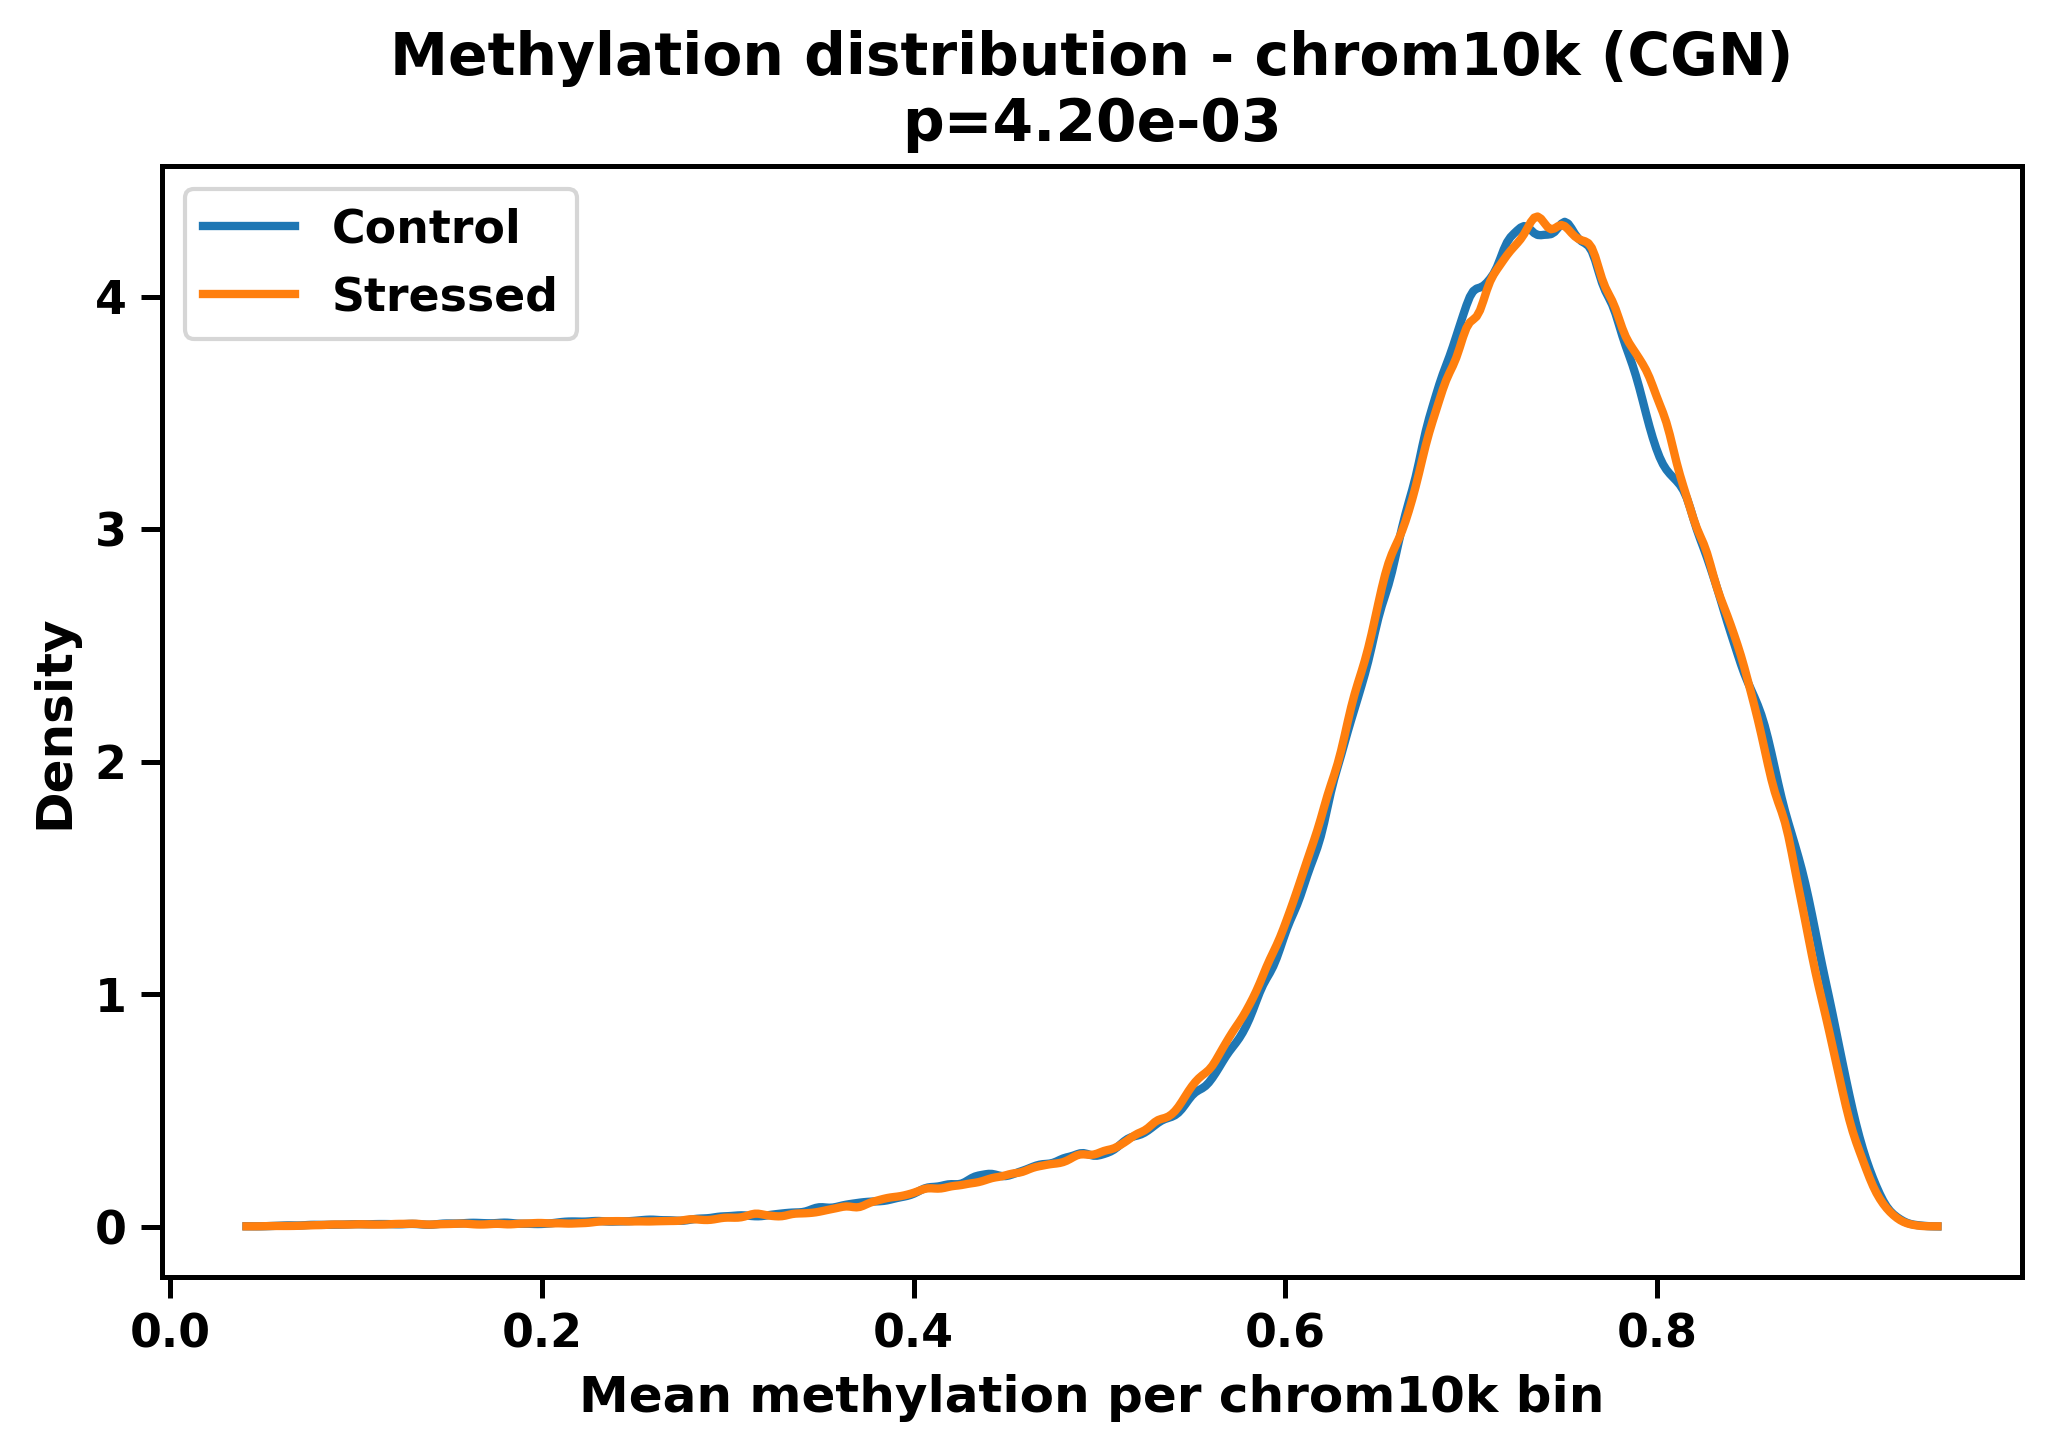

Saved: globalplots_per_feature_chrom10k/line_density_hist_chrom10k_CGN.pdf


In [65]:
# ================================
# Title: Per-feature distribution (memory-safe) + Welch t-test + line density
# What changed/added:
# 1) Avoid frac.to_pandas() (big RAM spike)
# 2) Use xarray groupby over cells to compute per-bin means per group
# 3) Use histogram-based density line (low memory) instead of seaborn KDE
# ================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.ndimage import gaussian_filter1d
from pathlib import Path


var_dim = "chrom10k"
group_coord = "cell_Group"   # in your MCDS coords
frac_var = "chrom10k_da_frac"

mc_type = "CGN"  # change to "CHN" for mCH

# 1) Get fraction (cell x chrom10k) as xarray (dask-backed)
frac = mcds[frac_var].sel(mc_type=mc_type)

# 2) Attach Group as a coordinate along cell (so groupby works)
frac = frac.assign_coords(Group=("cell", mcds.coords[group_coord].values))

# 3) Compute per-feature mean in each group WITHOUT making a huge pandas table
mean_by_group = frac.groupby("Group").mean(dim="cell")  # dims: Group x chrom10k

# 4) Pull just the 2 vectors we need (each length ~271k)
control_bins  = mean_by_group.sel(Group="Control").compute().values.astype(np.float32)
stressed_bins = mean_by_group.sel(Group="Stressed").compute().values.astype(np.float32)

# Drop NaNs/infs
mask = np.isfinite(control_bins) & np.isfinite(stressed_bins)
control_bins  = control_bins[mask]
stressed_bins = stressed_bins[mask]

print("Number of bins used:", len(control_bins))

# 5) Welch t-test (cheap)
t_stat, p_val = ttest_ind(control_bins, stressed_bins, equal_var=False)

# Cohen's d (effect size)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_sd

d = cohens_d(control_bins, stressed_bins)

print("Welch t-test p:", p_val)
print("Cohen's d:", d)

# 6) LINE density plot via histogram (very memory-friendly)
#    (optional smoothing to look like KDE)
n_bins=500
min_val = min(control_bins.min(), stressed_bins.min())
max_val = max(control_bins.max(), stressed_bins.max())

bin_edges = np.linspace(min_val, max_val, n_bins + 1)


h_c, _ = np.histogram(control_bins,  bins=bin_edges, 
                      density=True)
h_s, _ = np.histogram(stressed_bins,  bins=bin_edges, 
                      density=True)

x = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Smooth a bit to resemble KDE (optional)
sigma = 2
h_c_smooth = gaussian_filter1d(h_c, sigma=sigma)
h_s_smooth = gaussian_filter1d(h_s, sigma=sigma)

plt.figure(figsize=(7, 5))
plt.plot(x, h_c_smooth, linewidth=2, label="Control")
plt.plot(x, h_s_smooth, linewidth=2, label="Stressed")

plt.xlabel(f"Mean methylation per {var_dim} bin")
plt.ylabel("Density")
plt.title(f"Methylation distribution - {var_dim} ({mc_type})\n"
          f"p={p_val:.2e}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.pdf", dpi=300, transparent=True)
plt.savefig(OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.png", dpi=300, transparent=True)

plt.show()

print("Saved:", OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.pdf")

Number of bins: 278601
T-statistic: 50.97868234687563
P-value: 0.0
Cohen's d: 0.13658791272148885


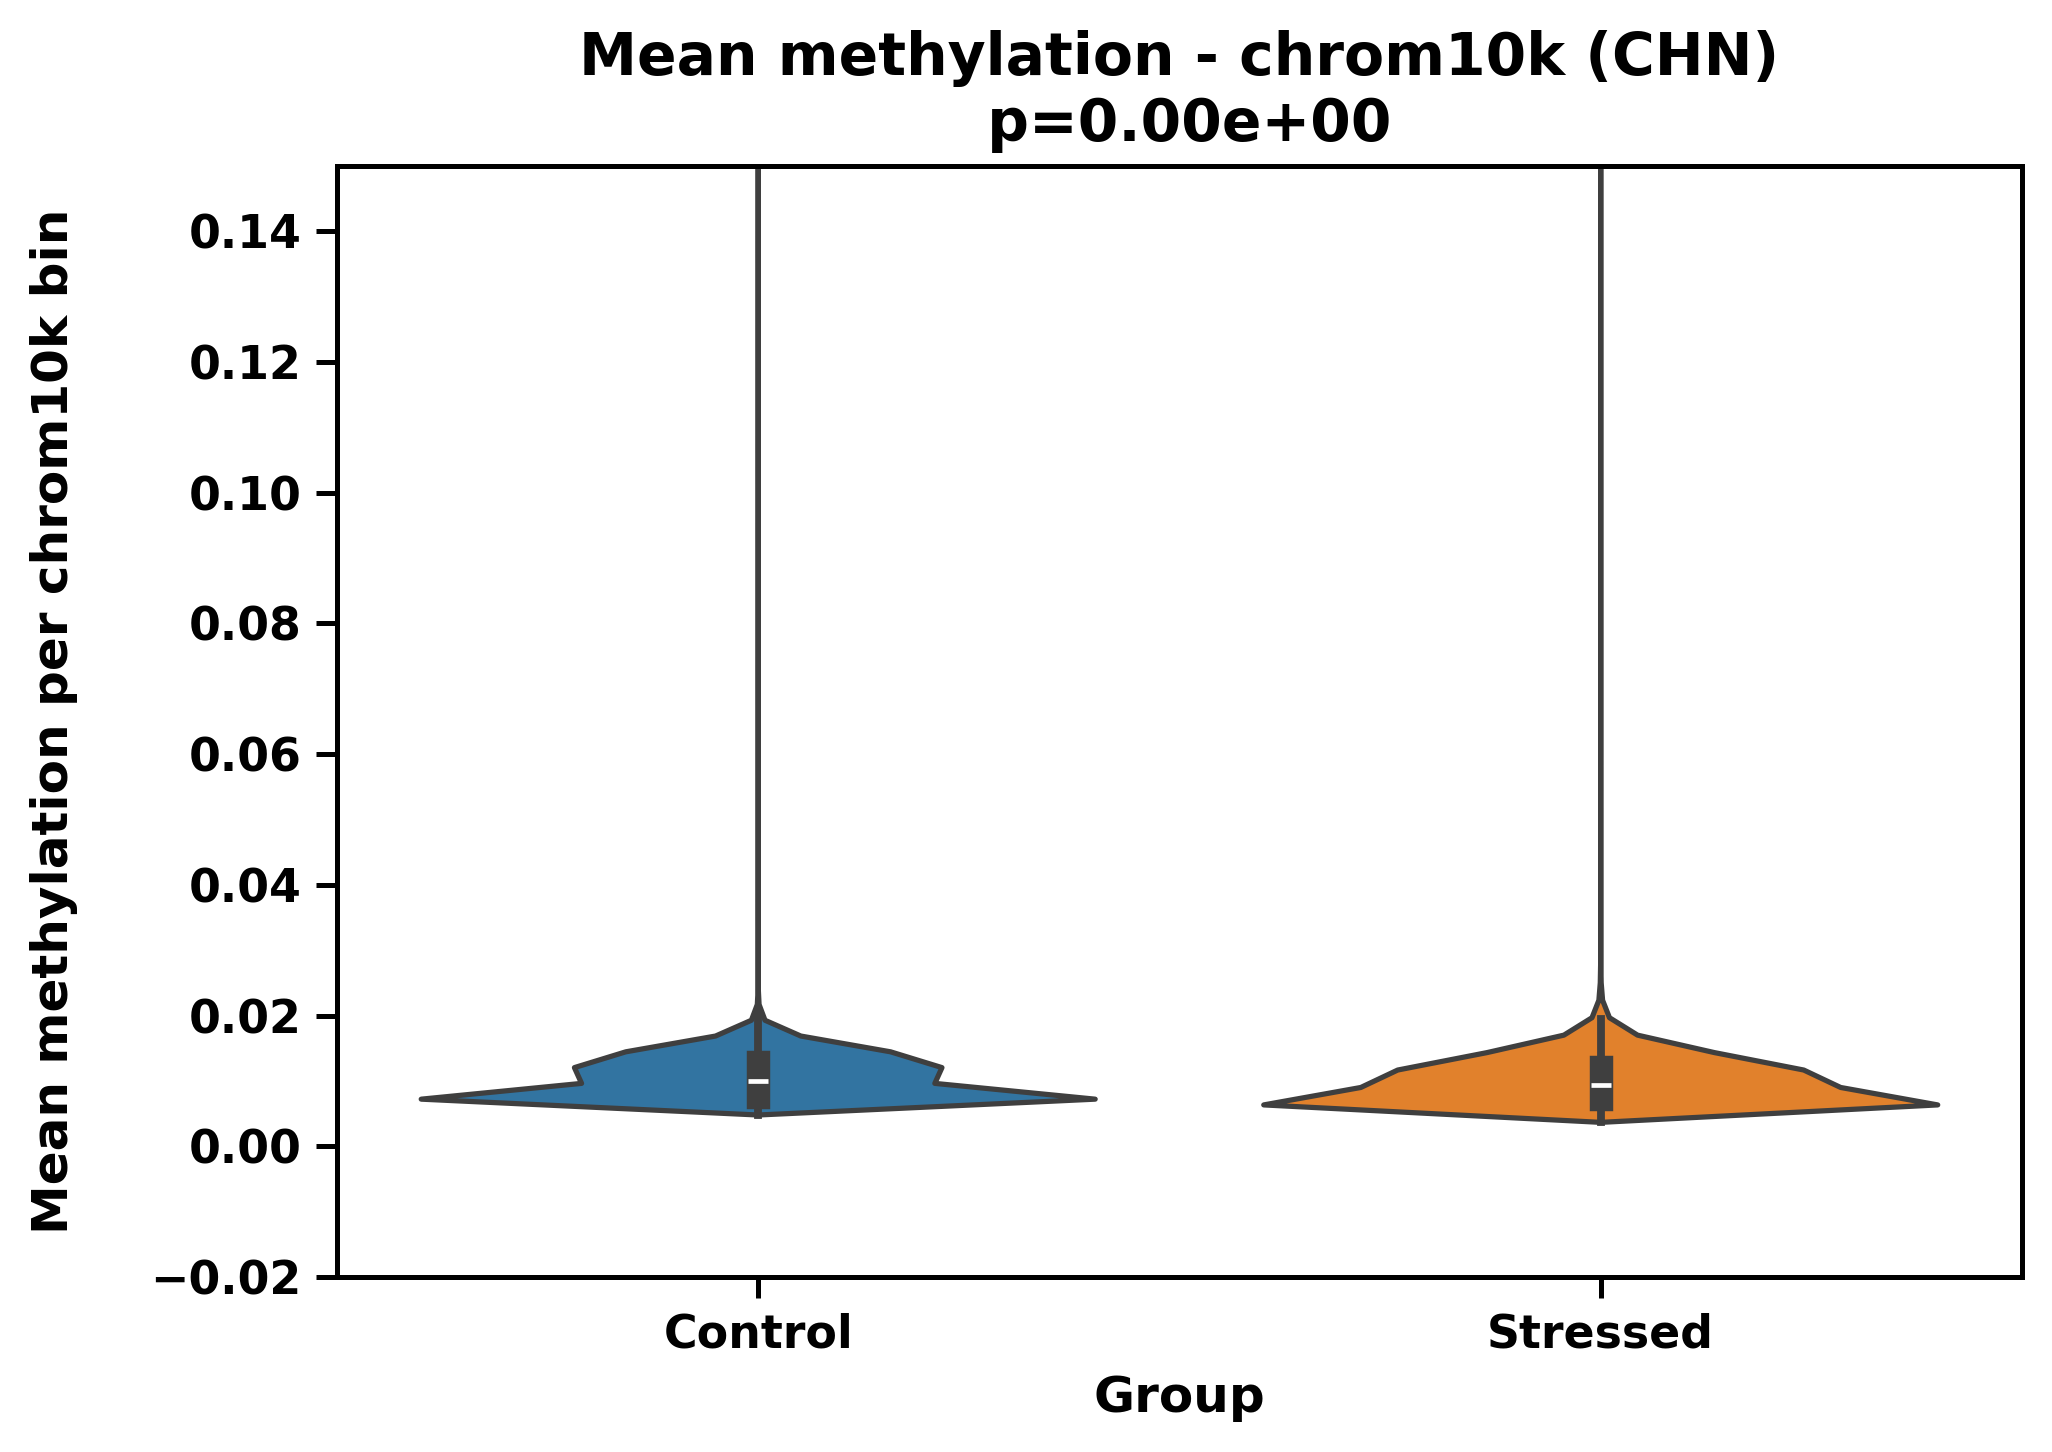

Plot saved to: globalplots_per_feature_chrom10k/violin_CHN_chrom10k_per_feature.pdf


In [67]:
# ============================================
# Title: Per-feature (chrom10k) methylation distribution + t-test
# What this does:
# 1) Compute mean methylation per bin per group
# 2) Build distribution across bins
# 3) Perform Welch’s t-test between groups (bins as units)
# 4) Plot violin distribution
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

OUT_DIR = Path("globalplots_per_feature_chrom10k")
OUT_DIR.mkdir(exist_ok=True)

mc_type = "CHN"  # change to "CHN" for mCH
var_dim = "chrom10k"  # just for labeling / filenames

# Extract fraction matrix (cell x chrom10k)
frac = mcds["chrom10k_da_frac"].sel(mc_type=mc_type)

# Convert to pandas (cells x bins)
frac_df = frac.to_pandas()

# Add group info (ensure alignment with frac_df rows)
frac_df["Group"] = mcds.coords["cell_Group"].to_pandas()

# Compute mean methylation per bin per group (Group x bins)
mean_by_bin = frac_df.groupby("Group").mean(numeric_only=True)

# Extract arrays (distribution across bins)
control_bins = mean_by_bin.loc["Control"].to_numpy()
stressed_bins = mean_by_bin.loc["Stressed"].to_numpy()

# Remove NaN/inf bins
mask = np.isfinite(control_bins) & np.isfinite(stressed_bins)
control_bins = control_bins[mask]
stressed_bins = stressed_bins[mask]

# ===================
# T-test (Welch)
# ===================
t_stat, p_val = ttest_ind(control_bins, stressed_bins, equal_var=False, nan_policy="omit")

# Effect size (Cohen's d using pooled SD)
def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx = x.size
    ny = y.size
    pooled_sd = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

d = cohens_d(control_bins, stressed_bins)

print("Number of bins:", len(control_bins))
print("T-statistic:", t_stat)
print("P-value:", p_val)
print("Cohen's d:", d)

# ===================
# Save stats summary
# ===================
stats_df = pd.DataFrame({
    "mc_type": [mc_type],
    "var_dim": [var_dim],
    "n_bins": [len(control_bins)],
    "t_statistic": [t_stat],
    "p_value": [p_val],
    "cohens_d": [d],
    "control_mean": [np.mean(control_bins)],
    "stressed_mean": [np.mean(stressed_bins)]
})

stats_df.to_csv(OUT_DIR / f"global_stats_{mc_type}_{var_dim}.csv", index=False)

# ===================
# Prepare plotting dataframe (long format)
# ===================
df_plot = pd.DataFrame({
    "Group": (["Control"] * len(control_bins)) +
             (["Stressed"] * len(stressed_bins)),
    "mean_methylation": np.concatenate([control_bins, stressed_bins])
})

df_plot.to_csv(OUT_DIR / f"distribution_values_{mc_type}_{var_dim}.csv", index=False)

# ===================
# Make a long-form df for seaborn
df_plot = pd.DataFrame({
    "Group": (["Control"] * len(control_bins)) + (["Stressed"] * len(stressed_bins)),
    "mean_methylation": np.concatenate([control_bins, stressed_bins])
})

# ===================
# Violin Plot
# ===================
plt.figure(figsize=(7, 5))
sns.violinplot(data=df_plot, x="Group", y="mean_methylation", inner="box", cut=0, hue="Group")

plt.title(f"Mean methylation - {var_dim} ({mc_type})\n p={p_val:.2e}")
plt.xlabel("Group")
plt.ylabel(f"Mean methylation per {var_dim} bin\n")
plt.ylim(-0.02,0.15)
plt.tight_layout()
outpath = OUT_DIR / f"violin_{mc_type}_{var_dim}_per_feature.pdf"
plt.savefig(outpath, dpi=300)
plt.savefig(OUT_DIR / f"violin_{mc_type}_{var_dim}_per_feature.png", dpi=300, transparent=True)
plt.show()

print("Plot saved to:", outpath)

Number of bins used: 278601
Welch t-test p: 0.0
Cohen's d: 0.136588086664356


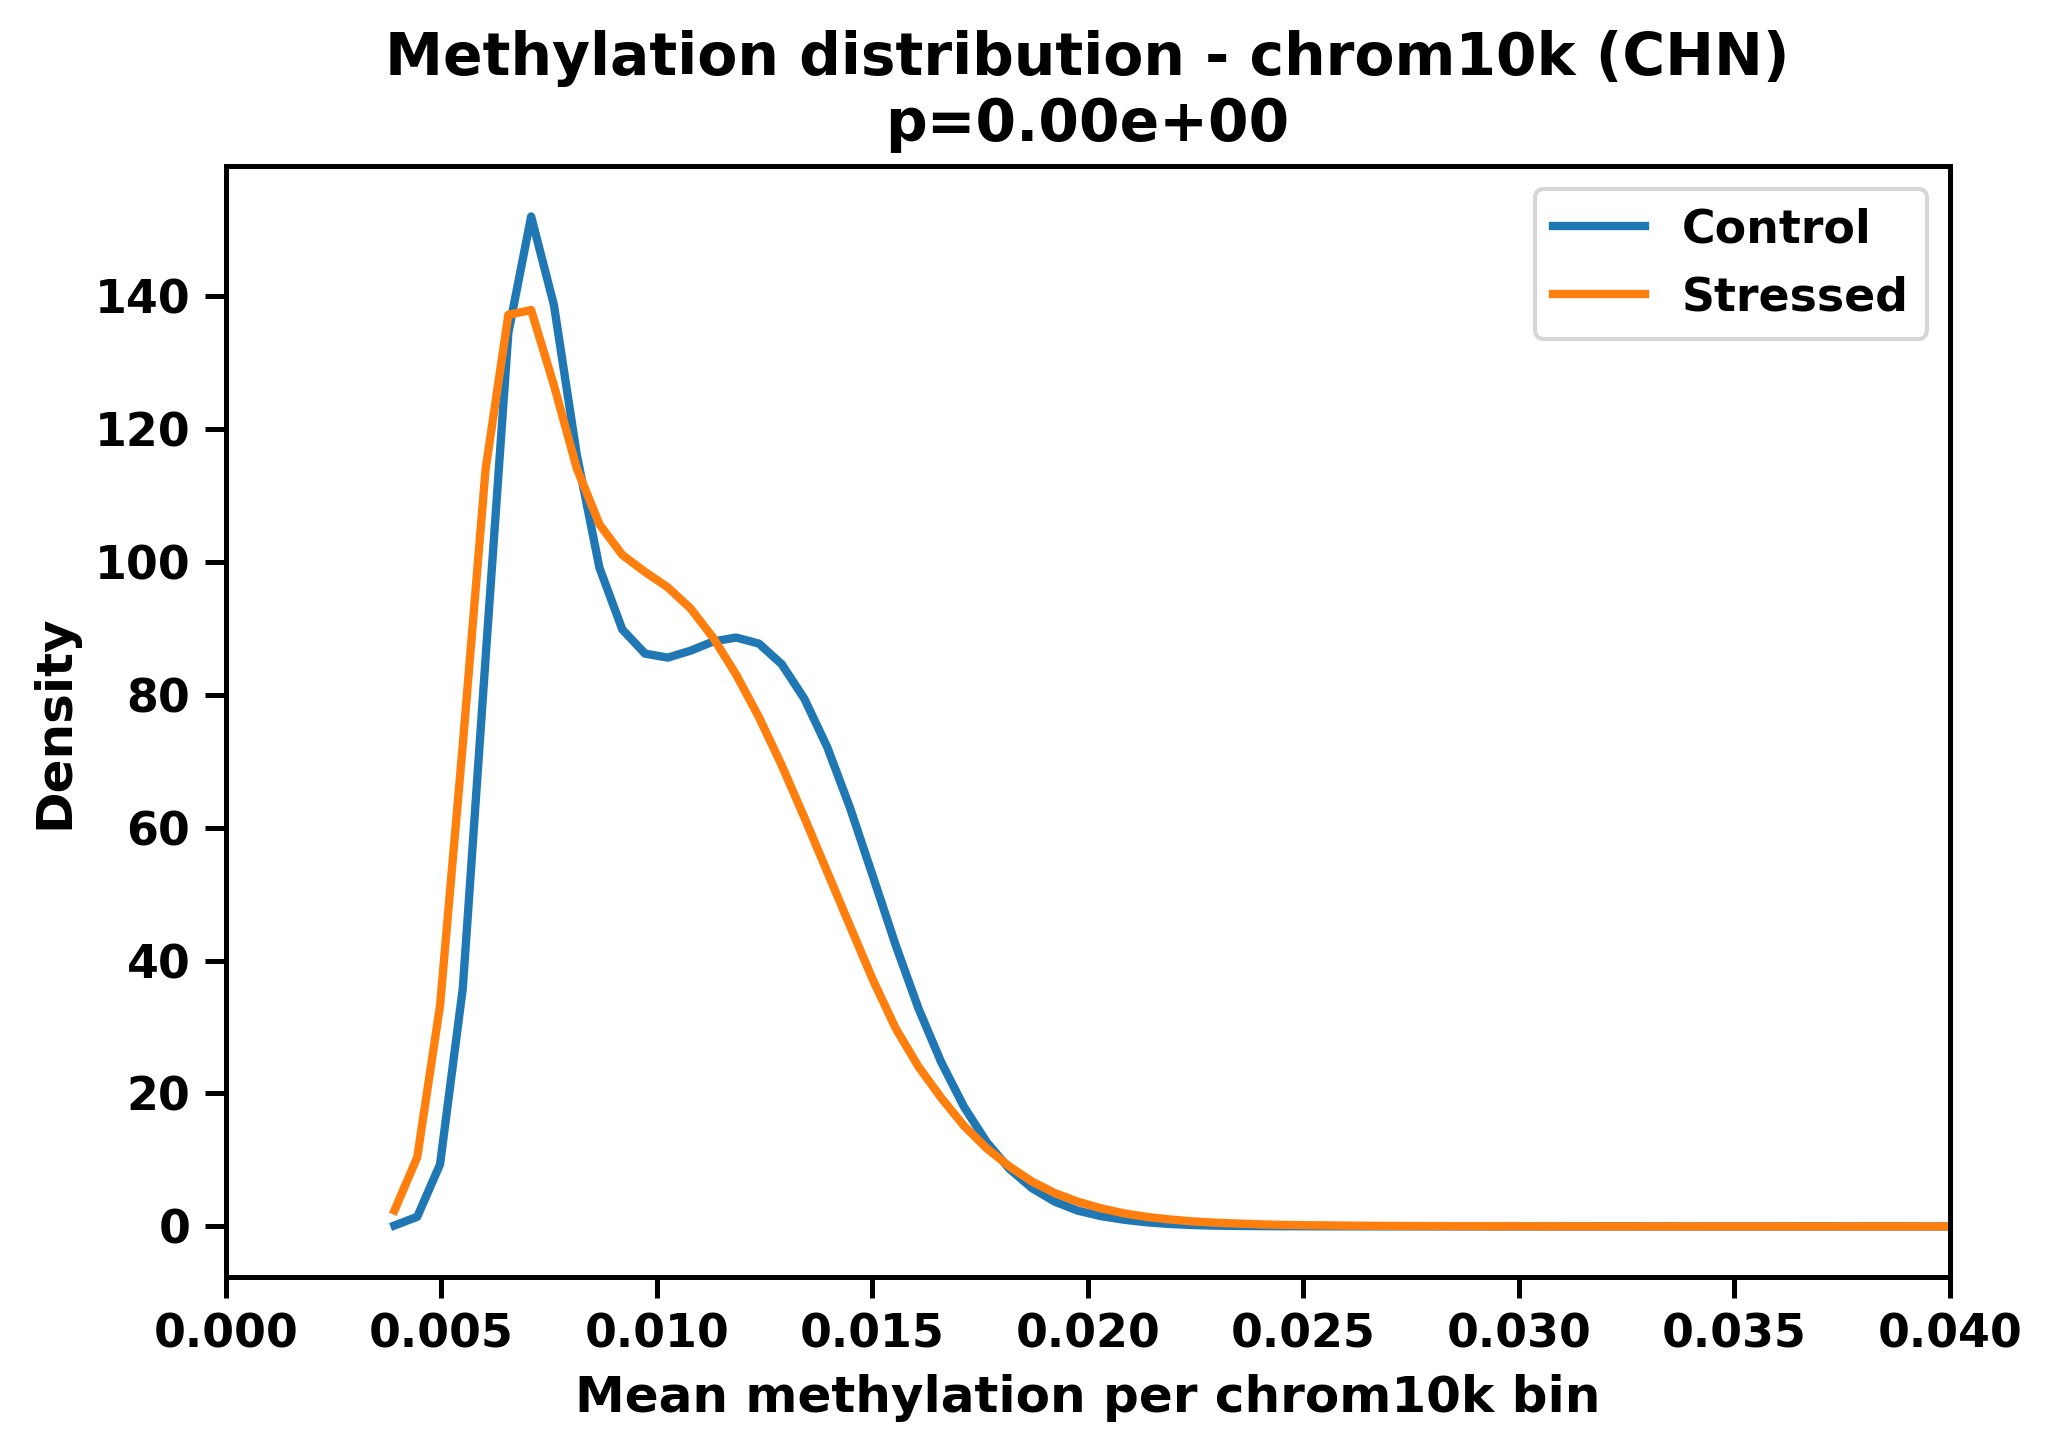

Saved: globalplots_per_feature_chrom10k/line_density_hist_chrom10k_CHN.pdf


In [66]:
# ================================
# Title: Per-feature distribution (memory-safe) + Welch t-test + line density
# What changed/added:
# 1) Avoid frac.to_pandas() (big RAM spike)
# 2) Use xarray groupby over cells to compute per-bin means per group
# 3) Use histogram-based density line (low memory) instead of seaborn KDE
# ================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

OUT_DIR = Path("globalplots_per_feature_chrom10k/")
OUT_DIR.mkdir(exist_ok=True)

var_dim = "chrom10k"
group_coord = "cell_Group"   # in your MCDS coords
frac_var = "chrom10k_da_frac"

mc_type = "CHN"  # change to "CHN" for mCH

# 1) Get fraction (cell x chrom10k) as xarray (dask-backed)
frac = mcds[frac_var].sel(mc_type=mc_type)

# 2) Attach Group as a coordinate along cell (so groupby works)
frac = frac.assign_coords(Group=("cell", mcds.coords[group_coord].values))

# 3) Compute per-feature mean in each group WITHOUT making a huge pandas table
mean_by_group = frac.groupby("Group").mean(dim="cell")  # dims: Group x chrom10k

# 4) Pull just the 2 vectors we need (each length ~271k)
control_bins  = mean_by_group.sel(Group="Control").compute().values.astype(np.float32)
stressed_bins = mean_by_group.sel(Group="Stressed").compute().values.astype(np.float32)

# Drop NaNs/infs
mask = np.isfinite(control_bins) & np.isfinite(stressed_bins)
control_bins  = control_bins[mask]
stressed_bins = stressed_bins[mask]

print("Number of bins used:", len(control_bins))

# 5) Welch t-test (cheap)
t_stat, p_val = ttest_ind(control_bins, stressed_bins, equal_var=False)

# Cohen's d (effect size)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_sd

d = cohens_d(control_bins, stressed_bins)

print("Welch t-test p:", p_val)
print("Cohen's d:", d)

# 6) LINE density plot via histogram (very memory-friendly)
#    (optional smoothing to look like KDE)
min_val = min(control_bins.min(), stressed_bins.min())
max_val = max(control_bins.max(), stressed_bins.max())

bin_edges = np.linspace(min_val, max_val, n_bins + 1)

h_c, _ = np.histogram(control_bins, bins=bin_edges, density=True)
h_s, _ = np.histogram(stressed_bins, bins=bin_edges, density=True)

x = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Smooth a bit to resemble KDE (optional)
sigma = 1
h_c_smooth = gaussian_filter1d(h_c, sigma=sigma)
h_s_smooth = gaussian_filter1d(h_s, sigma=sigma)

plt.figure(figsize=(7, 5))
plt.plot(x, h_c_smooth, linewidth=2, label="Control")
plt.plot(x, h_s_smooth, linewidth=2, label="Stressed")
plt.xlim(0, 0.04)
plt.xlabel(f"Mean methylation per {var_dim} bin")
plt.ylabel("Density")
plt.title(f"Methylation distribution - {var_dim} ({mc_type})\n"
          f"p={p_val:.2e}")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.pdf", dpi=300, transparent=True)
plt.savefig(OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.png", dpi=300, transparent=True)
plt.show()

print("Saved:", OUT_DIR / f"line_density_hist_{var_dim}_{mc_type}.pdf")